# Stage 1 — Zero-Shot CLIP RN50

This independent Colab notebook evaluates frozen **CLIP RN50** image and text encoders on **DTD partition 1**, **FGVC-Aircraft (variant)**, and **Oxford Flowers-102**. It uses the exact dataset-specific prompt templates from Stage 1, the complete official test splits, cosine similarity, and one result per dataset. Zero-shot CLIP uses no labeled training images and trains no parameters.

## 1. Install dependencies

In [1]:
%pip -q install open_clip_torch scikit-learn pandas seaborn tqdm


## 2. Mount Drive and configure paths

In [2]:
from pathlib import Path
USE_DRIVE = True
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Flow-Matching')
else:
    PROJECT_ROOT = Path('/content/Flow-Matching')
PERSISTENT_DATA_ROOT = PROJECT_ROOT / 'data'
DATA_ROOT = Path('/content/flow_matching_data') if Path('/content').exists() else PERSISTENT_DATA_ROOT
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'zero_shot_clip'
CACHE_ROOT = PROJECT_ROOT / 'feature_cache' / 'clip_rn50'
for p in [DATA_ROOT,OUTPUT_ROOT,CACHE_ROOT]: p.mkdir(parents=True,exist_ok=True)
print('Project root:',PROJECT_ROOT,'| dataset root:',DATA_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Flow-Matching | dataset root: /content/flow_matching_data


## 3. Imports, GPU detection, and reproducibility

In [ ]:
import json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
import open_clip

DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); PIN_MEMORY=DEVICE.type=='cuda'
print('Device:',DEVICE,'| GPU:',torch.cuda.get_device_name(0) if PIN_MEMORY else 'none')
DATASETS=['dtd','aircraft','flowers102']; BATCH_SIZE=128; NUM_WORKERS=2
random.seed(0); np.random.seed(0); torch.manual_seed(0)


In [4]:
DEFAULT_STAGE1 = {'config_revision': 5, 'plan': {'datasets': ['dtd', 'aircraft', 'flowers102'], 'prototype_branch': 'all', 'prototype_branches': ['image', 'zero_shot_clip']}, 'feature_cache': {'batch_size': 64, 'num_workers': 0}, 'zero_shot_clip': {'output_subdir': 'zero_shot_clip', 'model_name': 'RN50', 'pretrained': 'openai', 'force_quick_gelu': True, 'cache_schema_version': 2, 'primary_variant': 'prescribed'}}
config_paths = [PROJECT_ROOT / 'stage1_config.json', Path.cwd() / 'stage1_config.json', Path('/content/stage1_config.json')]
config_path = next((p for p in config_paths if p.exists()), None)
if config_path is None:
    STAGE1 = DEFAULT_STAGE1
    print('stage1_config.json not found; using comprehensive embedded configuration.')
else:
    with config_path.open() as f: STAGE1 = json.load(f)
    print('Loaded configuration from:', config_path)
if STAGE1.get('config_revision', 0) < 3: STAGE1 = DEFAULT_STAGE1
PLAN = STAGE1['plan']
assert 'zero_shot_clip' in PLAN.get('prototype_branches', [PLAN.get('prototype_branch')]), 'Zero-shot CLIP is not enabled.'
DATASETS = PLAN['datasets']
BATCH_SIZE = min(STAGE1['feature_cache']['batch_size'], 64); NUM_WORKERS = 0 if Path('/content').exists() else STAGE1['feature_cache']['num_workers']
CLIP_CFG = STAGE1.get('zero_shot_clip', DEFAULT_STAGE1['zero_shot_clip'])
MODEL_NAME=CLIP_CFG.get('model_name','RN50'); PRETRAINED=CLIP_CFG.get('pretrained','openai'); FORCE_QUICK_GELU=bool(CLIP_CFG.get('force_quick_gelu',True)); CACHE_SCHEMA=int(CLIP_CFG.get('cache_schema_version',2)); PRIMARY_VARIANT=CLIP_CFG.get('primary_variant','prescribed')
OUTPUT_ROOT=PROJECT_ROOT/'outputs'/CLIP_CFG.get('output_subdir','zero_shot_clip'); CACHE_ROOT=PROJECT_ROOT/'feature_cache'/f'clip_{MODEL_NAME.lower()}_{PRETRAINED}_qgelu{int(FORCE_QUICK_GELU)}_v{CACHE_SCHEMA}'
OUTPUT_ROOT.mkdir(parents=True,exist_ok=True); CACHE_ROOT.mkdir(parents=True,exist_ok=True)
print('CLIP:',MODEL_NAME,PRETRAINED,'| QuickGELU:',FORCE_QUICK_GELU,'| cache:',CACHE_ROOT)


Loaded configuration from: /content/drive/MyDrive/Flow-Matching/stage1_config.json
CLIP: RN50 openai | QuickGELU: True | cache: /content/drive/MyDrive/Flow-Matching/feature_cache/clip_rn50_openai_qgelu1_v2


## 4. Official class names and required prompt templates
The required Stage 1 single-prompt result is retained as `prescribed`. A separately reported `ensemble` variant averages multiple normalized text embeddings per class; it remains frozen and zero-shot and never uses labels.

In [5]:
FLOWERS102_CLASSES = [
'pink primrose','hard-leaved pocket orchid','canterbury bells','sweet pea','english marigold','tiger lily','moon orchid','bird of paradise','monkshood','globe thistle',
'snapdragon','colts foot','king protea','spear thistle','yellow iris','globe-flower','purple coneflower','peruvian lily','balloon flower','giant white arum lily',
'fire lily','pincushion flower','fritillary','red ginger','grape hyacinth','corn poppy','prince of wales feathers','stemless gentian','artichoke','sweet william',
'carnation','garden phlox','love in the mist','mexican aster','alpine sea holly','ruby-lipped cattleya','cape flower','great masterwort','siam tulip','lenten rose',
'barbeton daisy','daffodil','sword lily','poinsettia','bolero deep blue','wallflower','marigold','buttercup','oxeye daisy','common dandelion',
'petunia','wild pansy','primula','sunflower','pelargonium','bishop of llandaff','gaura','geranium','orange dahlia','pink-yellow dahlia',
'cautleya spicata','japanese anemone','black-eyed susan','silverbush','californian poppy','osteospermum','spring crocus','bearded iris','windflower','tree poppy',
'gazania','azalea','water lily','rose','thorn apple','morning glory','passion flower','lotus','toad lily','anthurium',
'frangipani','clematis','hibiscus','columbine','desert-rose','tree mallow','magnolia','cyclamen','watercress','canna lily',
'hippeastrum','bee balm','ball moss','foxglove','bougainvillea','camellia','mallow','mexican petunia','bromelia','blanket flower','trumpet creeper','blackberry lily']
assert len(FLOWERS102_CLASSES)==102
PRESCRIBED={'dtd':['a photo of a {class_name} texture'],'aircraft':['a photo of a {class_name} aircraft'],'flowers102':['a photo of a {class_name} flower']}
ENSEMBLE={'dtd':['a photo of a {class_name} texture','a close-up photo of a {class_name} texture','a cropped photo of a {class_name} surface','a detailed photo of a {class_name} pattern','a texture that is {class_name}'],'aircraft':['a photo of a {class_name} aircraft','a photo of the {class_name}, a type of aircraft','a side-view photo of a {class_name} aircraft','a photo of a {class_name} airplane in flight','a close-up photo of a {class_name} airplane'],'flowers102':['a photo of a {class_name} flower','a close-up photo of a {class_name} flower','a photo of a blooming {class_name}','a detailed photo of the petals of a {class_name} flower','a photo of a {class_name} in a garden']}
PROMPT_VARIANTS=CLIP_CFG.get('prompt_variants',{'prescribed':PRESCRIBED,'ensemble':ENSEMBLE})
assert PRIMARY_VARIANT in PROMPT_VARIANTS and set(DATASETS)<=set(PROMPT_VARIANTS[PRIMARY_VARIANT])
# Compatibility alias for an already-open pre-revision-5 embedding cell in VS Code/Colab.
PROMPT_TEMPLATES={name:templates[0] for name,templates in PROMPT_VARIANTS['prescribed'].items()}


## 5. Load frozen CLIP RN50 and official test datasets
OpenCLIP's `openai` RN50 checkpoint and its associated validation preprocessing are used. The encoder is kept in evaluation mode with gradients disabled.

In [6]:
model,_,preprocess=open_clip.create_model_and_transforms(MODEL_NAME,pretrained=PRETRAINED,force_quick_gelu=FORCE_QUICK_GELU); tokenizer=open_clip.get_tokenizer(MODEL_NAME)
model.eval().to(DEVICE)
for p in model.parameters(): p.requires_grad_(False)
assert not any(p.requires_grad for p in model.parameters())

def build_test_dataset(name,transform):
    if name=='dtd': return datasets.DTD(DATA_ROOT,split='test',partition=1,transform=transform,download=True)
    if name=='aircraft': return datasets.FGVCAircraft(DATA_ROOT,split='test',annotation_level='variant',transform=transform,download=True)
    if name=='flowers102': return datasets.Flowers102(DATA_ROOT,split='test',transform=transform,download=True)
    raise ValueError(name)

def targets_of(ds):
    for attr in ('_labels','targets','labels'):
        if hasattr(ds,attr): return np.asarray(getattr(ds,attr),dtype=int)
    return np.asarray([ds[i][1] for i in range(len(ds))],dtype=int)

def class_names_of(name,ds):
    if name=='flowers102': return FLOWERS102_CLASSES
    if hasattr(ds,'classes'): return [str(x).replace('_',' ') for x in ds.classes]
    raise AttributeError(f'No class names exposed for {name}')

test_datasets={name:build_test_dataset(name,preprocess) for name in DATASETS}
for name,ds in test_datasets.items():
    names=class_names_of(name,ds); labels=targets_of(ds); assert len(names)==int(labels.max())+1
    print(name,len(ds),'images',len(names),'classes')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


dtd 1880 images 47 classes
aircraft 3333 images 100 classes
flowers102 6149 images 102 classes


## 6. Show input samples
These are classification inputs, not generated images; Stage 1 contains no generative model.

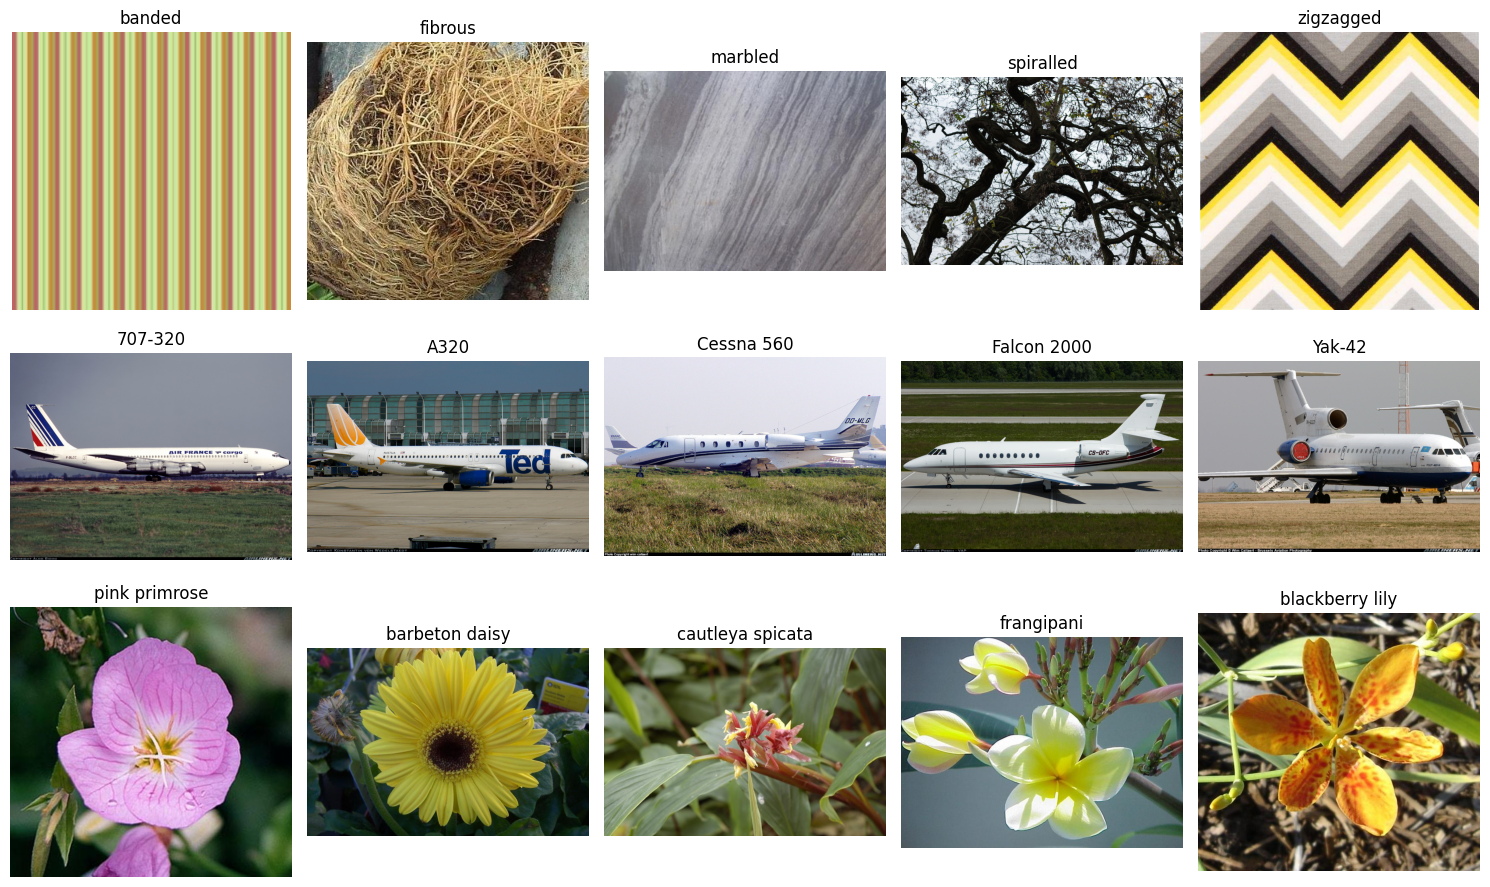

In [7]:
fig,axes=plt.subplots(3,5,figsize=(15,9))
for row,name in enumerate(DATASETS):
    raw=build_test_dataset(name,None); names=class_names_of(name,raw)
    for col,idx in enumerate(np.linspace(0,len(raw)-1,5,dtype=int)):
        image,label=raw[idx]; axes[row,col].imshow(image); axes[row,col].set_title(names[label][:28]); axes[row,col].axis('off')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT/'input_samples.png',dpi=180,bbox_inches='tight'); plt.show()


## 7. Cache normalized image and text embeddings

In [ ]:
@torch.inference_mode()
def encode_dataset(name,ds):
    cache=CACHE_ROOT/f'{name}__test.pt'
    if cache.exists(): return torch.load(cache,map_location='cpu',weights_only=False)
    loader=DataLoader(ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY); zs=[]; ys=[]
    for images,labels in tqdm(loader,desc=f'CLIP RN50 / {name}'):
        zs.append(F.normalize(model.encode_image(images.to(DEVICE,non_blocking=True)).float(),dim=1).cpu()); ys.append(labels.long())
    item=dict(features=torch.cat(zs),labels=torch.cat(ys),classes=class_names_of(name,ds),dataset=name,encoder=f'CLIP {MODEL_NAME}',model_name=MODEL_NAME,pretrained=PRETRAINED,force_quick_gelu=FORCE_QUICK_GELU,cache_schema=CACHE_SCHEMA)
    assert len(item['features'])==len(ds) and torch.isfinite(item['features']).all(); torch.save(item,cache); return item

@torch.inference_mode()
def encode_text_prototypes(name,class_names,variant,templates):
    cache=CACHE_ROOT/f'{name}__text_{variant}.pt'
    if cache.exists():
        cached=torch.load(cache,map_location='cpu',weights_only=False)
        if cached.get('classes')==class_names and cached.get('templates')==templates:
            return cached['features'],cached['prompts']
    all_prompts=[[template.format(class_name=c) for template in templates] for c in class_names]
    flat=[p for class_prompts in all_prompts for p in class_prompts]; tokens=tokenizer(flat).to(DEVICE)
    encoded=F.normalize(model.encode_text(tokens).float(),dim=1).view(len(class_names),len(templates),-1)
    z=F.normalize(encoded.mean(1),dim=1).cpu()
    torch.save(dict(features=z,classes=class_names,prompts=all_prompts,variant=variant,templates=templates,encoder=f'CLIP {MODEL_NAME}',force_quick_gelu=FORCE_QUICK_GELU,cache_schema=CACHE_SCHEMA),cache)
    return z,all_prompts

embedding_bank={}; text_bank_by_variant={}; prompt_bank_by_variant={}
for name,ds in test_datasets.items():
    embedding_bank[name]=encode_dataset(name,ds)
    for variant,by_dataset in PROMPT_VARIANTS.items(): text_bank_by_variant[(variant,name)],prompt_bank_by_variant[(variant,name)]=encode_text_prototypes(name,embedding_bank[name]['classes'],variant,by_dataset[name])
text_bank={n:text_bank_by_variant[(PRIMARY_VARIANT,n)] for n in DATASETS}; prompt_bank={n:prompt_bank_by_variant[(PRIMARY_VARIANT,n)] for n in DATASETS}
display(pd.DataFrame([{'dataset':n,'variant':v,'prompt example':prompt_bank_by_variant[(v,n)][0][0],'templates':len(PROMPT_VARIANTS[v][n]),'images':len(embedding_bank[n]['labels']),'classes':len(text_bank_by_variant[(v,n)])} for v in PROMPT_VARIANTS for n in DATASETS]))


## 8. Zero-shot cosine classification and top-1 accuracy
Because both embedding sets are unit-normalized, their dot product is cosine similarity. There is one result per dataset and no validation-based selection.

Enhanced CLIP evaluation active: ['prescribed', 'ensemble'] | primary: prescribed


,dataset,variant,test_accuracy,templates_per_class
0,dtd,prescribed,0.3979,1
1,aircraft,prescribed,0.1704,1
2,flowers102,prescribed,0.6360,1
3,dtd,ensemble,0.4207,5
4,aircraft,ensemble,0.1692,5
5,flowers102,ensemble,0.6560,5


,dataset,test_accuracy_prescribed,test_accuracy_ensemble,improvement_pp
0,dtd,0.3979,0.4207,+2.29
1,aircraft,0.1704,0.1692,-0.12
2,flowers102,0.6360,0.6560,+2.00


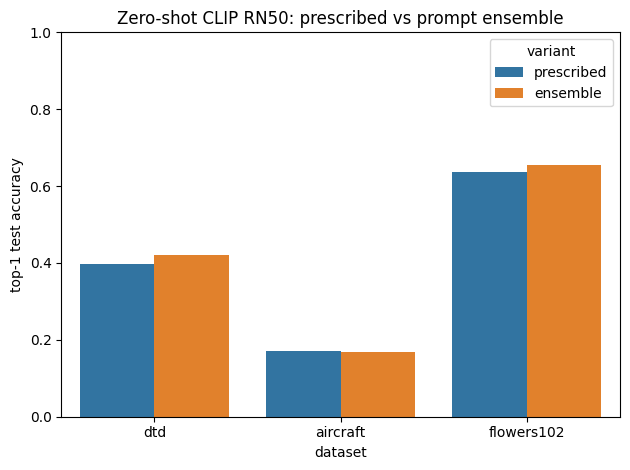

In [9]:
assert 'prescribed' in PROMPT_VARIANTS and 'ensemble' in PROMPT_VARIANTS, 'Enhanced prompt variants are missing; restart and run all cells.'
print('Enhanced CLIP evaluation active:',list(PROMPT_VARIANTS),'| primary:',PRIMARY_VARIANT)
rows=[]; predictions_by_variant={}; scores_by_variant={}; logit_scale=float(model.logit_scale.exp().detach().cpu())
for variant in PROMPT_VARIANTS:
  for name in DATASETS:
    images=embedding_bank[name]['features']; labels=embedding_bank[name]['labels']; cosine_scores=images@text_bank_by_variant[(variant,name)].T; scores=logit_scale*cosine_scores; pred=scores.argmax(1); acc=(pred==labels).float().mean().item()
    predictions_by_variant[(variant,name)]=pred; scores_by_variant[(variant,name)]=scores
    run_dir=OUTPUT_ROOT/'runs'/variant/name; run_dir.mkdir(parents=True,exist_ok=True)
    np.save(run_dir/'test_predictions.npy',pred.numpy()); np.save(run_dir/'cosine_scores.npy',cosine_scores.numpy()); np.save(run_dir/'scaled_logits.npy',scores.numpy())
    metrics=dict(dataset=name,encoder=f'CLIP {MODEL_NAME}',baseline='zero-shot text prototypes',variant=variant,is_stage1_primary=variant==PRIMARY_VARIANT,test_accuracy=acc,num_test_images=len(labels),num_classes=len(text_bank_by_variant[(variant,name)]),templates_per_class=len(PROMPT_VARIANTS[variant][name]),logit_scale=logit_scale,force_quick_gelu=FORCE_QUICK_GELU,cache_schema=CACHE_SCHEMA)
    (run_dir/'metrics.json').write_text(json.dumps(metrics,indent=2)); rows.append(metrics)
results_df=pd.DataFrame(rows); assert len(results_df)==len(DATASETS)*len(PROMPT_VARIANTS), 'Incomplete CLIP variant grid.'; primary_df=results_df[results_df.variant==PRIMARY_VARIANT].copy(); ensemble_df=results_df[results_df.variant=='ensemble'].copy()
results_df.to_csv(OUTPUT_ROOT/'variant_accuracy_summary.csv',index=False); primary_df.to_csv(OUTPUT_ROOT/'accuracy_summary.csv',index=False); ensemble_df.to_csv(OUTPUT_ROOT/'enhanced_accuracy_summary.csv',index=False)
prediction_bank={n:predictions_by_variant[(PRIMARY_VARIANT,n)] for n in DATASETS}; score_bank={n:scores_by_variant[(PRIMARY_VARIANT,n)] for n in DATASETS}
display(results_df[['dataset','variant','test_accuracy','templates_per_class']].style.format({'test_accuracy':'{:.4f}'}))
comparison=primary_df[['dataset','test_accuracy']].merge(ensemble_df[['dataset','test_accuracy']],on='dataset',suffixes=('_prescribed','_ensemble')); comparison['improvement_pp']=100*(comparison.test_accuracy_ensemble-comparison.test_accuracy_prescribed); display(comparison.style.format({'test_accuracy_prescribed':'{:.4f}','test_accuracy_ensemble':'{:.4f}','improvement_pp':'{:+.2f}'})); comparison.to_csv(OUTPUT_ROOT/'prompt_ensemble_comparison.csv',index=False)
ax=sns.barplot(data=results_df,x='dataset',y='test_accuracy',hue='variant'); ax.set_ylim(0,1); ax.set(title=f'Zero-shot CLIP {MODEL_NAME}: prescribed vs prompt ensemble',ylabel='top-1 test accuracy'); plt.tight_layout(); plt.savefig(OUTPUT_ROOT/'accuracy.png',dpi=180,bbox_inches='tight'); plt.show()


## 9. Row-normalized confusion matrices

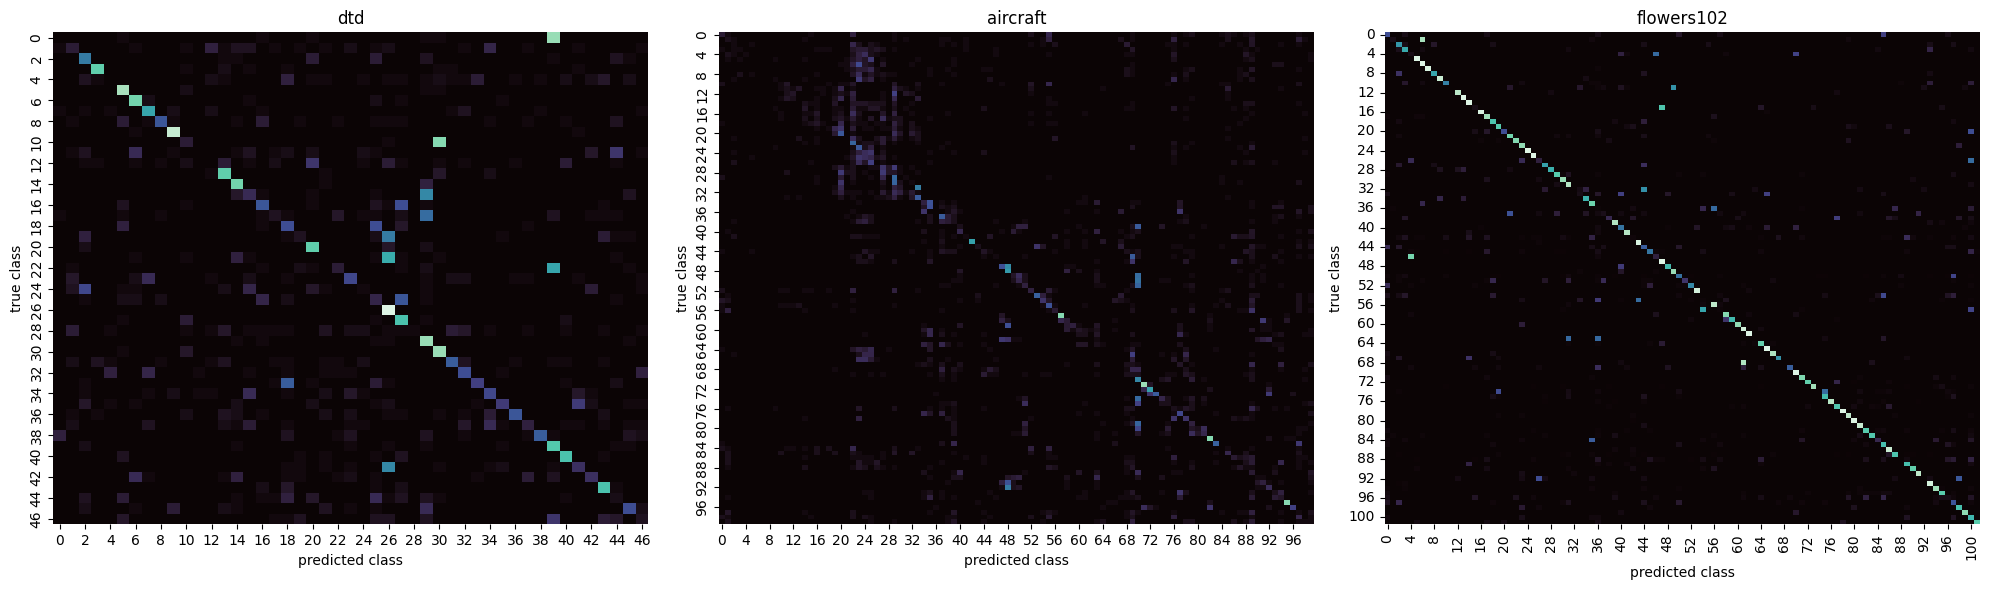

In [10]:
fig,axes=plt.subplots(1,3,figsize=(20,6))
for ax,name in zip(axes,DATASETS):
    y=embedding_bank[name]['labels'].numpy(); pred=prediction_bank[name].numpy(); sns.heatmap(confusion_matrix(y,pred,normalize='true'),cmap='mako',vmin=0,vmax=1,cbar=False,ax=ax); ax.set(title=name,xlabel='predicted class',ylabel='true class')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT/'confusion_matrices.png',dpi=180,bbox_inches='tight'); plt.show()


## 10. Joint PCA and t-SNE of image embeddings and text prototypes
The first 10 classes and up to 30 deterministic test examples per class are shown. PCA and t-SNE are both fitted jointly to the displayed image embeddings and corresponding text prototypes, shown side by side per dataset. Class colors stay consistent within each plot; the result is qualitative.

In [ ]:
fig,axes=plt.subplots(1,len(DATASETS)*2,figsize=(9*len(DATASETS),5))
for i,name in enumerate(DATASETS):
    bank=embedding_bank[name]; y=bank['labels'].numpy(); selected=np.arange(10); idx=np.concatenate([np.flatnonzero(y==c)[:30] for c in selected]); image_z=bank['features'][idx]; text_z=text_bank[name][selected]
    joint=torch.cat([image_z,text_z]).numpy(); n=len(image_z)
    pca_xy=PCA(n_components=2).fit_transform(joint)
    perplexity=min(30,max(5,n-1)); tsne_xy=TSNE(n_components=2,perplexity=perplexity,init='pca',random_state=0).fit_transform(joint)
    pca_ax,tsne_ax=axes[2*i],axes[2*i+1]
    sns.scatterplot(x=pca_xy[:n,0],y=pca_xy[:n,1],hue=y[idx],palette='tab10',s=22,alpha=.65,legend=False,ax=pca_ax); pca_ax.scatter(pca_xy[n:,0],pca_xy[n:,1],c=selected,cmap='tab10',marker='X',s=160,edgecolors='black'); pca_ax.set(title=f'{name} (PCA)',xlabel='PC1',ylabel='PC2')
    sns.scatterplot(x=tsne_xy[:n,0],y=tsne_xy[:n,1],hue=y[idx],palette='tab10',s=22,alpha=.65,legend=False,ax=tsne_ax); tsne_ax.scatter(tsne_xy[n:,0],tsne_xy[n:,1],c=selected,cmap='tab10',marker='X',s=160,edgecolors='black'); tsne_ax.set(title=f'{name} (t-SNE)',xlabel='dim 1',ylabel='dim 2')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT/'joint_image_text_pca_tsne.png',dpi=180,bbox_inches='tight'); plt.show()


## 11. Representative predictions and errors
The gallery shows confidence, ground truth, and prediction for deterministic test examples. Images are loaded from the same official test split without model preprocessing only for display.

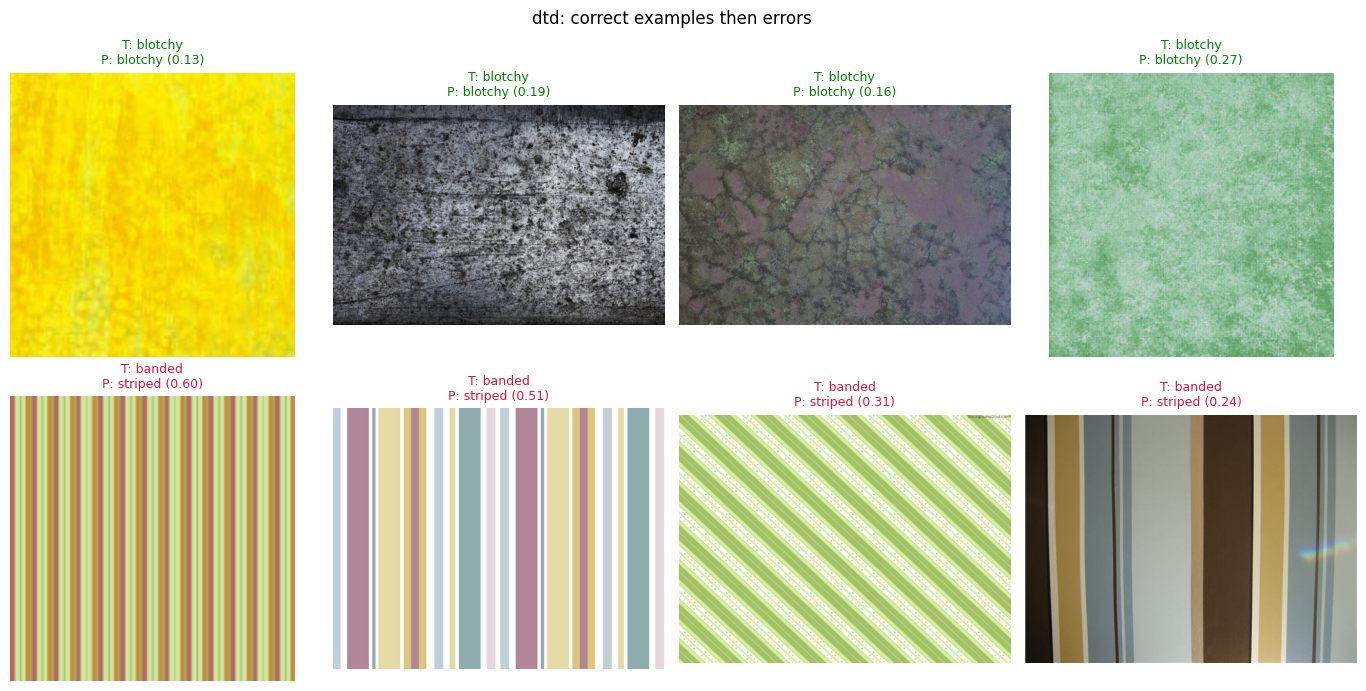

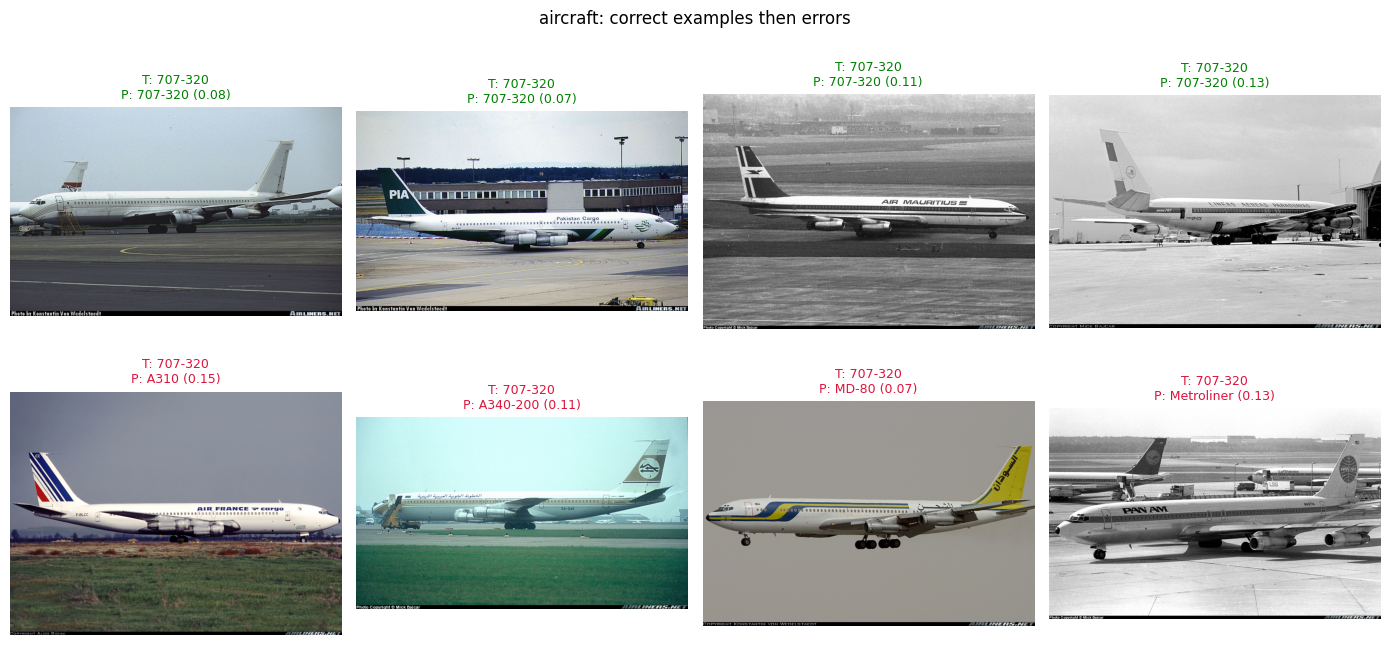

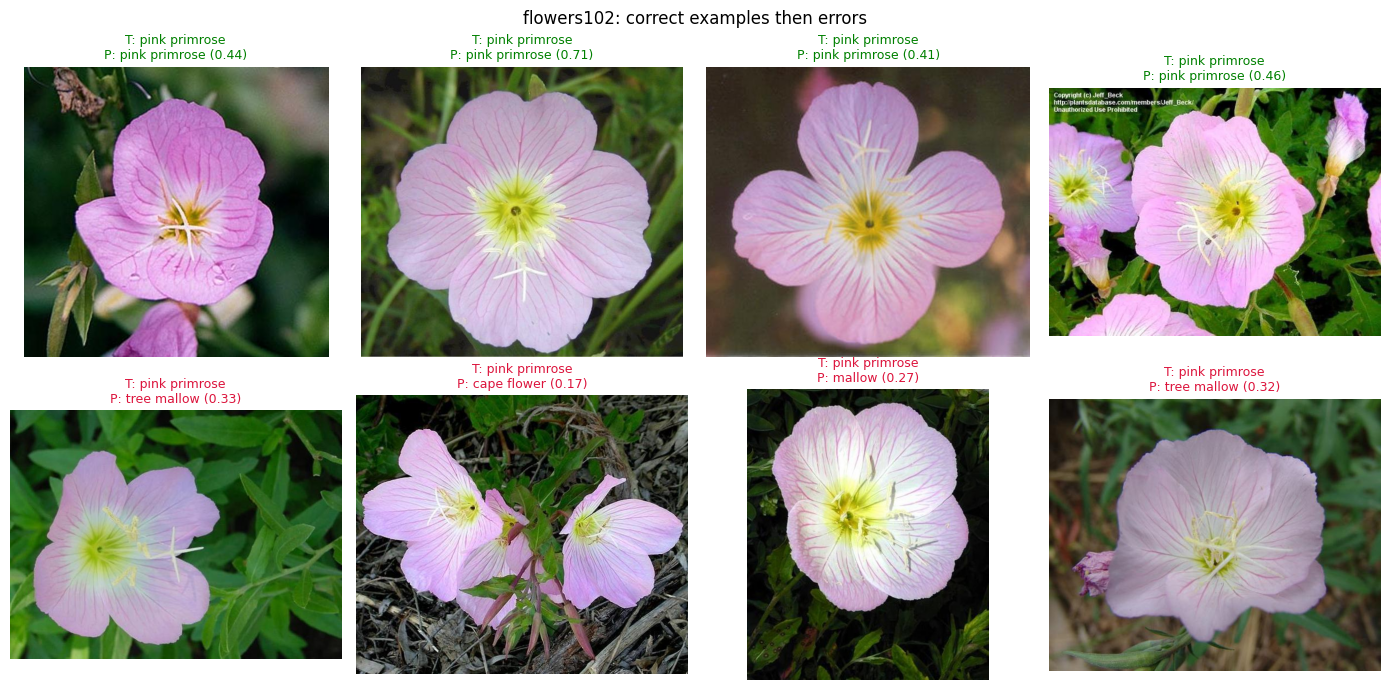

Artifacts saved to: /content/drive/MyDrive/Flow-Matching/outputs/zero_shot_clip


In [12]:
for name in DATASETS:
    raw=build_test_dataset(name,None); names=embedding_bank[name]['classes']; y=embedding_bank[name]['labels']; pred=prediction_bank[name]; confidence=score_bank[name].softmax(1).max(1).values
    correct=torch.nonzero(pred==y,as_tuple=True)[0][:4].tolist(); wrong=torch.nonzero(pred!=y,as_tuple=True)[0][:4].tolist(); chosen=correct+wrong
    fig,axes=plt.subplots(2,4,figsize=(14,7)); axes=axes.ravel()
    for ax,idx in zip(axes,chosen):
        image,_=raw[idx]; ax.imshow(image); ax.set_title(f'T: {names[y[idx]][:20]}\nP: {names[pred[idx]][:20]} ({confidence[idx]:.2f})',color='green' if pred[idx]==y[idx] else 'crimson',fontsize=9); ax.axis('off')
    for ax in axes[len(chosen):]: ax.axis('off')
    fig.suptitle(f'{name}: correct examples then errors'); fig.tight_layout(); fig.savefig(OUTPUT_ROOT/f'{name}_prediction_gallery.png',dpi=180,bbox_inches='tight'); plt.show()
print('Artifacts saved to:',OUTPUT_ROOT)
